In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
def classify_traffic(volume):
    if volume < 2000:
        return "Low"––
    elif volume < 4000:
        return "Medium"
    else:
        return "High"

df["congestion_level"] = df["traffic_volume"].apply(classify_traffic)
df["congestion_level"].value_counts()

,count
congestion_level,
High,20939
Low,15219
Medium,12046


In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'])

df['hour'] = df['date_time'].dt.hour
df['day'] = df['date_time'].dt.day
df['month'] = df['date_time'].dt.month
df['weekday'] = df['date_time'].dt.weekday

df.drop('date_time', axis=1, inplace=True)
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,congestion_level,hour,day,month,weekday
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,5545,High,9,2,10,1
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,4516,High,10,2,10,1
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,4767,High,11,2,10,1
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,5026,High,12,2,10,1
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,4918,High,13,2,10,1


In [ ]:
le = LabelEncoder()

for col in ['holiday', 'weather_main', 'weather_description']:
    df[col] = le.fit_transform(df[col])

# Encode target for classification
target_encoder = LabelEncoder()
df['congestion_encoded'] = target_encoder.fit_transform(df['congestion_level'])

df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,traffic_volume,congestion_level,hour,day,month,weekday,congestion_encoded
0,11,288.28,0.0,0.0,40,1,24,5545,High,9,2,10,1,0
1,11,289.36,0.0,0.0,75,1,2,4516,High,10,2,10,1,0
2,11,289.58,0.0,0.0,90,1,19,4767,High,11,2,10,1,0
3,11,290.13,0.0,0.0,90,1,19,5026,High,12,2,10,1,0
4,11,291.14,0.0,0.0,75,1,2,4918,High,13,2,10,1,0


In [ ]:
X_cls = df.drop(['traffic_volume', 'congestion_level', 'congestion_encoded'], axis=1)
y_cls = df['congestion_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

In [ ]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred_cls = clf.predict(X_test)

print("Classification Accuracy:", accuracy_score(y_test, y_pred_cls))
print(classification_report(y_test, y_pred_cls))

Classification Accuracy: 0.9491753967430765
              precision    recall  f1-score   support

           0       0.96      0.98      0.97      4241
           1       0.97      0.96      0.96      3032
           2       0.91      0.89      0.90      2368

    accuracy                           0.95      9641
   macro avg       0.94      0.94      0.94      9641
weighted avg       0.95      0.95      0.95      9641



In [ ]:
X_reg = df.drop(['traffic_volume', 'congestion_level', 'congestion_encoded'], axis=1)
y_reg = df['traffic_volume']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [ ]:
reg = RandomForestRegressor(n_estimators=100, random_state=42)
reg.fit(X_train_r, y_train_r)

y_pred_reg = reg.predict(X_test_r)

print("MAE:", mean_absolute_error(y_test_r, y_pred_reg))
print("R2 Score:", r2_score(y_test_r, y_pred_reg))

MAE: 214.77987864329427
R2 Score: 0.9635809343677566


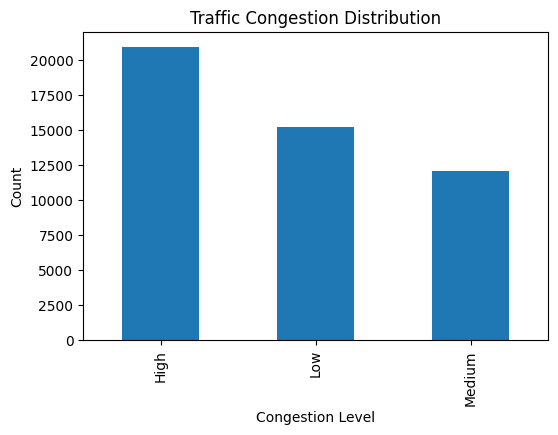

In [ ]:
plt.figure(figsize=(6,4))
df['congestion_level'].value_counts().plot(kind='bar')
plt.title("Traffic Congestion Distribution")
plt.xlabel("Congestion Level")
plt.ylabel("Count")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv("Metro_Interstate_Traffic_Volume.csv")
df.head()

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
def classify_traffic(volume):
    if volume < 2000:
        return "Low"
    elif volume < 4000:
        return "Medium"
    else:
        return "High"

df["congestion_level"] = df["traffic_volume"].apply(classify_traffic)

In [ ]:
df["date_time"] = pd.to_datetime(df["date_time"])

df["hour"] = df["date_time"].dt.hour
df["day"] = df["date_time"].dt.day
df["month"] = df["date_time"].dt.month
df["weekday"] = df["date_time"].dt.weekday
df["is_weekend"] = df["weekday"].apply(lambda x: 1 if x >= 5 else 0)

df.drop("date_time", axis=1, inplace=True)

In [ ]:
le = LabelEncoder()

for col in ["holiday", "weather_main", "weather_description"]:
    df[col] = le.fit_transform(df[col])

# Encode target
target_encoder = LabelEncoder()
df["congestion_encoded"] = target_encoder.fit_transform(df["congestion_level"])

In [ ]:
features = [
    "temp",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "weather_main",
    "weather_description",
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "holiday",
]

X = df[features]
y = df["congestion_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9482418836220309
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      4241
           1       0.97      0.96      0.96      3032
           2       0.90      0.89      0.90      2368

    accuracy                           0.95      9641
   macro avg       0.94      0.94      0.94      9641
weighted avg       0.95      0.95      0.95      9641



In [ ]:
# Example new input
sample_input = pd.DataFrame([{
    "temp": 18,
    "rain_1h": 0,
    "snow_1h": 0,
    "clouds_all": 10,
    "weather_main": df["weather_main"].mode()[0],
    "weather_description": df["weather_description"].mode()[0],
    "hour": 8,
    "day": 15,
    "month": 6,
    "weekday": 0,
    "is_weekend": 0,
    "holiday": df["holiday"].mode()[0],
}])

pred = model.predict(sample_input)
label = target_encoder.inverse_transform(pred)

print("Predicted Congestion Level:", label[0])

Predicted Congestion Level: High


In [ ]:
# ----- Take user input -----

temp = float(input("Enter temperature: "))
rain_1h = float(input("Enter rain in last hour: "))
snow_1h = float(input("Enter snow in last hour: "))
clouds_all = int(input("Enter cloud percentage: "))
hour = int(input("Enter hour (0-23): "))
day = int(input("Enter day of month (1-31): "))
month = int(input("Enter month (1-12): "))
weekday = int(input("Enter weekday (0=Mon ... 6=Sun): "))
is_weekend = int(input("Is weekend? (1=Yes, 0=No): "))

# For categorical fields, use most common value (safe default)
weather_main_val = df["weather_main"].mode()[0]
weather_desc_val = df["weather_description"].mode()[0]
holiday_val = df["holiday"].mode()[0]

# ----- Create input dataframe -----

user_input = pd.DataFrame([{
    "temp": temp,
    "rain_1h": rain_1h,
    "snow_1h": snow_1h,
    "clouds_all": clouds_all,
    "weather_main": weather_main_val,
    "weather_description": weather_desc_val,
    "hour": hour,
    "day": day,
    "month": month,
    "weekday": weekday,
    "is_weekend": is_weekend,
    "holiday": holiday_val,
}])

# ----- Predict -----

pred = model.predict(user_input)
label = target_encoder.inverse_transform(pred)

print("\n🚦 Predicted Congestion Level:", label[0])

Enter temperature: 22
Enter rain in last hour: 0
Enter snow in last hour: 0
Enter cloud percentage: 5
Enter hour (0-23): 2
Enter day of month (1-31): 10
Enter month (1-12): 3
Enter weekday (0=Mon ... 6=Sun): 2
Is weekend? (1=Yes, 0=No): 0

🚦 Predicted Congestion Level: Low


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score, f1_score

# Predictions already computed as y_pred

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("📊 MODEL EVALUATION")
print("---------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

📊 MODEL EVALUATION
---------------------
Accuracy : 0.9482
Precision: 0.9481
Recall   : 0.9482
F1 Score : 0.9481


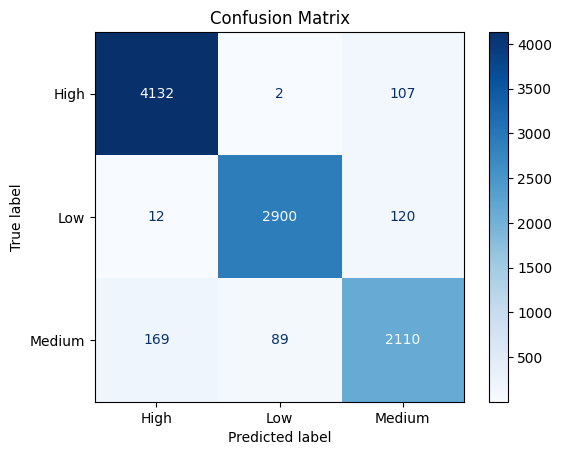

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
print("📄 Detailed Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=target_encoder.classes_))

📄 Detailed Classification Report:

              precision    recall  f1-score   support

        High       0.96      0.97      0.97      4241
         Low       0.97      0.96      0.96      3032
      Medium       0.90      0.89      0.90      2368

    accuracy                           0.95      9641
   macro avg       0.94      0.94      0.94      9641
weighted avg       0.95      0.95      0.95      9641

